# 🫀1. HEART DISEASE PREDICTION
## An End-to-End Machine Learning Classification Project

---
### 🩺 Problem Statement

The objective is to develop a **Machine Learning classification model** that predicts whether a patient is likely to have **heart disease** based on clinical attributes such as **age, blood pressure, cholesterol, chest pain type, maximum heart rate, exercise-induced angina, ST depression**, and other recorded health measurements.

### 📊 Project Overview

**Objective:** Predict the presence or absence of heart disease using patient health-related features.

**Machine Learning Type:** Supervised Learning  
**Problem Type:** Binary Classification  
**Target Variable:** `Heart Disease`

**2.Import Necessary Libraries**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report
)

import joblib

**3.Data collection**

## 📂 Dataset Source

The dataset used in this project is the **Heart Disease Prediction dataset**, obtained from **Kaggle**.
The dataset used in this project is based on real-world medical data and is derived from the UCI Heart Disease dataset. It is available through Kaggle and contains clinical information collected for heart disease analysis.

**Dataset Source:** Kaggle  
**Original Source: UCI Heart Disease Dataset**
**Dataset Name:** Heart Disease Prediction  
**Dataset Author:** Rishi Damarla  
**Dataset Type:** Publicly available medical dataset  
**Problem Type:** Binary Classification  
**Target Variable:** `Heart Disease`

### NOTE:-
Note: This dataset is not a randomly generated dummy dataset. It is derived from real-world clinical data and is used for educational and Machine Learning research purposes.

In [6]:
df = pd.read_csv(r"C:\Users\sujee\Desktop\Heart_disease prediction1\Heart_Disease_Prediction.csv")
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


**4.Understanding the dataset**

In [7]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [8]:
df.tail()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [9]:
df.shape

(270, 14)

In [10]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [12]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [13]:
print(df["Sex"].value_counts())

Sex
1    183
0     87
Name: count, dtype: int64


In [14]:
df["Heart Disease"].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

In [15]:
print(df["Heart Disease"].unique())

['Presence' 'Absence']


In [16]:
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


In [17]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

**5. Exploratory Data Analysis**

**5.1 Missing value summary**

In [18]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame(
    {
        "missing_count": missing_count,
        "missing_percent": missing_percent
    }
)
print("Missing Values Summary")
missing_summary

Missing Values Summary


,missing_count,missing_percent
Age,0,0.0
Sex,0,0.0
Chest pain type,0,0.0
BP,0,0.0
Cholesterol,0,0.0
FBS over 120,0,0.0
EKG results,0,0.0
Max HR,0,0.0
Exercise angina,0,0.0
ST depression,0,0.0


**5.2 Missing values**

In [19]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [20]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


**5.3 Duplicate values**

In [21]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
265    False
266    False
267    False
268    False
269    False
Length: 270, dtype: bool

In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**5.4. Target Distribution**

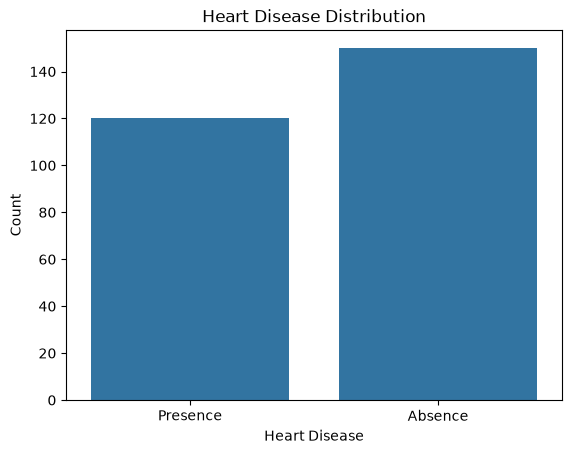

In [23]:
sns.countplot(data=df, x="Heart Disease")

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

**5.5 Univariate Analysis**

**5.5.1Age distribution**

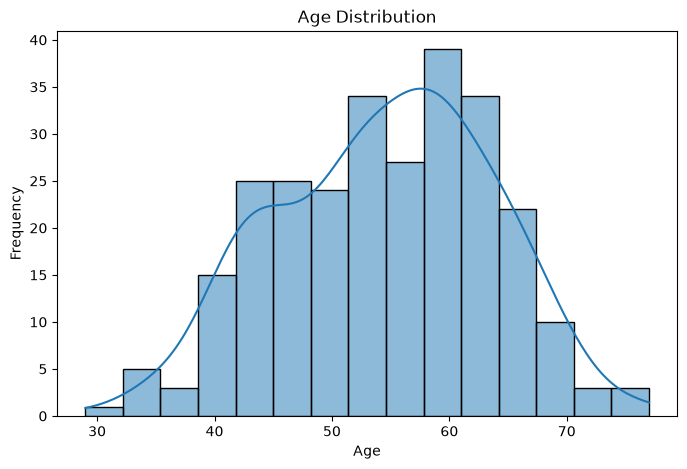

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

**5.5.2 Cholesterol distribution**

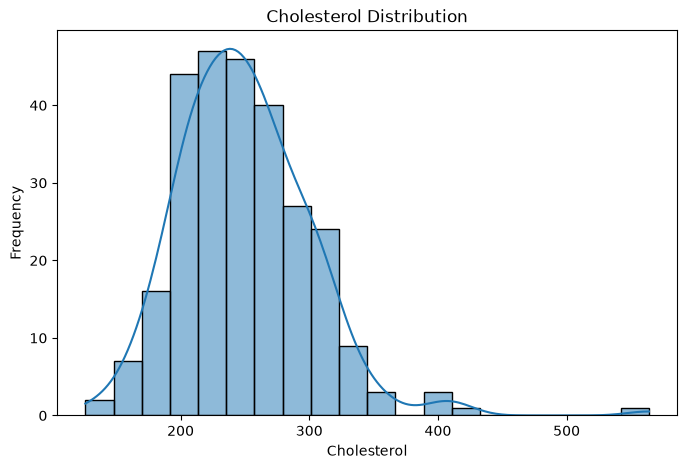

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["Cholesterol"], bins=20, kde=True)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

**5.5.3 Maximum Heart Rate**

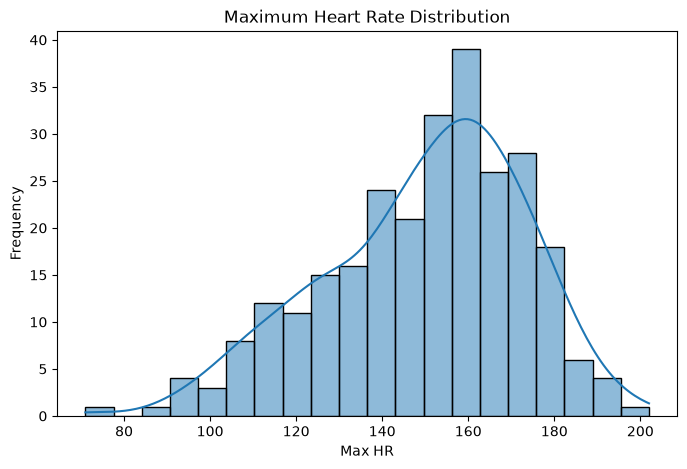

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df["Max HR"], bins=20, kde=True)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Max HR")
plt.ylabel("Frequency")

plt.show()

**5.6  Bivariate Analysis**

Compare features against the target.

**5.6.1 Age vs Heart Disease**

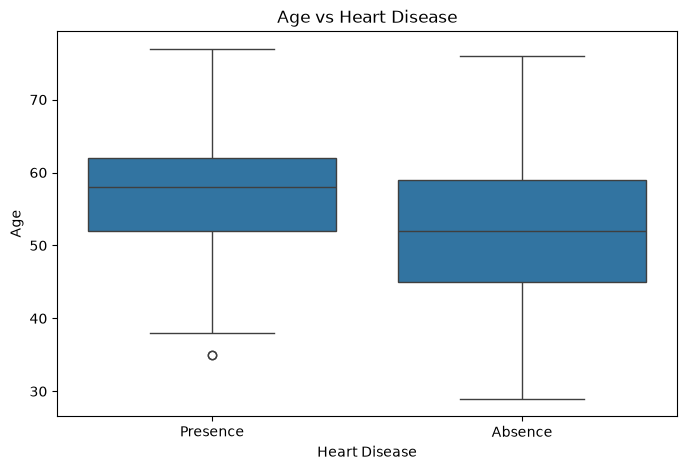

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Heart Disease",
    y="Age"
)

plt.title("Age vs Heart Disease")

plt.show()

**5.6.2 Cholesterol vs Heart Disease**


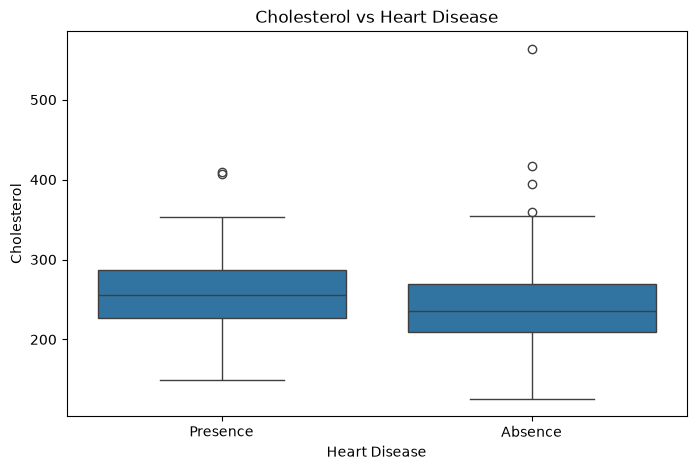

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Heart Disease",
    y="Cholesterol"
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

**5.6.3 Maximum Heart Rate vs Heart Disease**

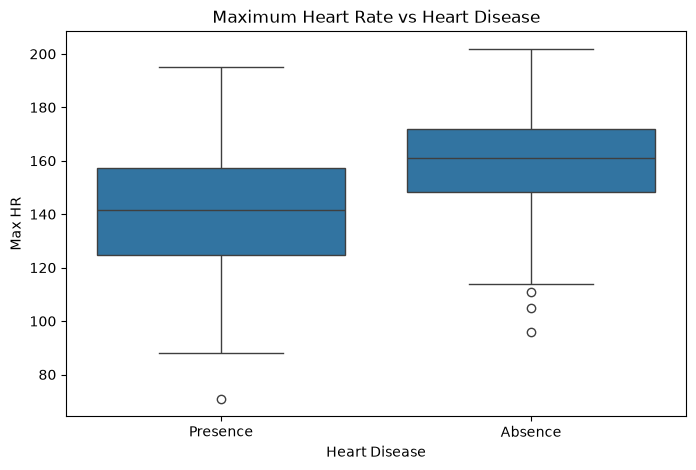

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Heart Disease",
    y="Max HR"
)

plt.title("Maximum Heart Rate vs Heart Disease")

plt.show()

**5.6.4 Chest pain vs target**

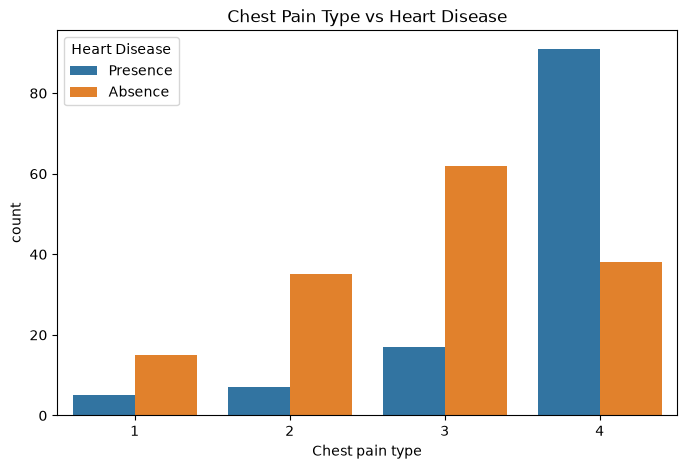

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Chest pain type",
    hue="Heart Disease"
)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

**5.7 Correlation Analysis**

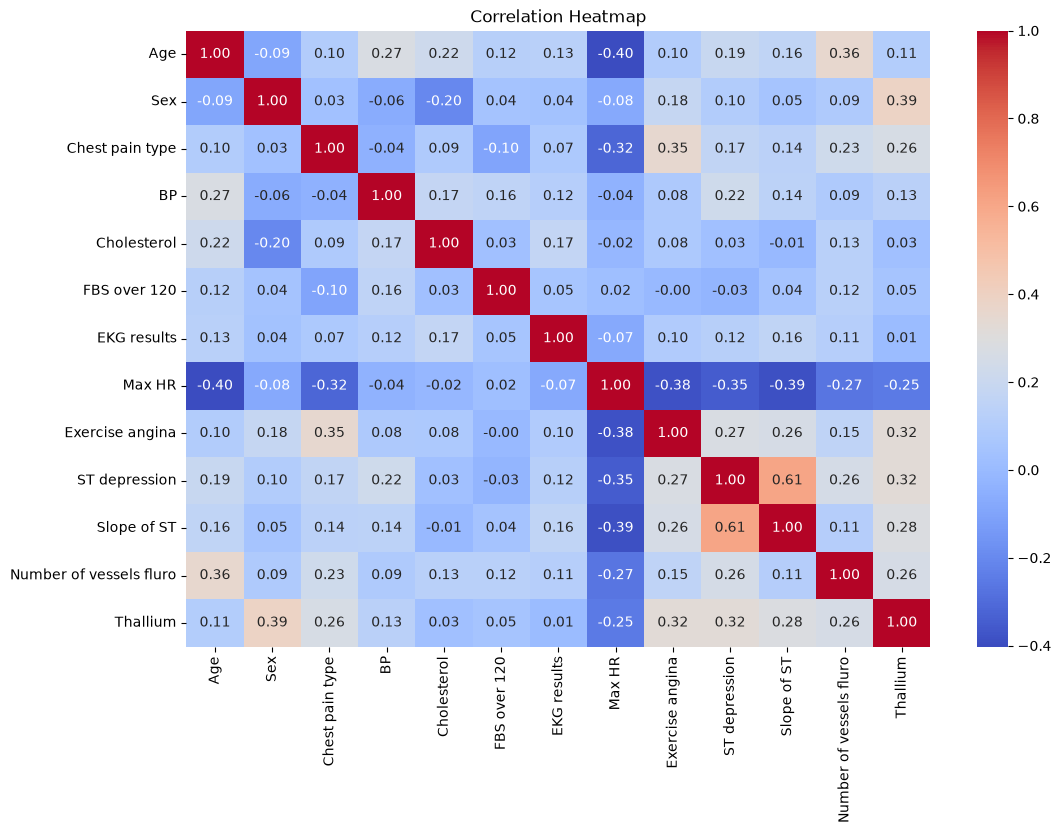

In [31]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

**6.Data Cleaning**

**6.1 Check Outliers**

In [32]:
continuous_columns = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

In [33]:
outlier_report = []

for column in continuous_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_report.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

outlier_report = pd.DataFrame(outlier_report)

print(outlier_report)

         Feature     Q1     Q3   IQR  Lower Bound  Upper Bound  Outlier Count
0            Age   48.0   61.0  13.0         28.5         80.5              0
1             BP  120.0  140.0  20.0         90.0        170.0              9
2    Cholesterol  213.0  280.0  67.0        112.5        380.5              5
3         Max HR  133.0  166.0  33.0         83.5        215.5              1
4  ST depression    0.0    1.6   1.6         -2.4          4.0              4


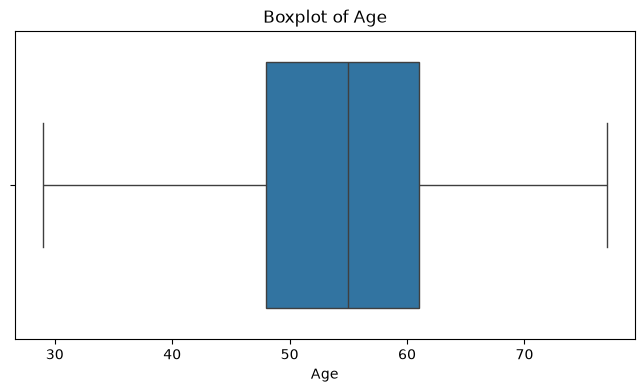

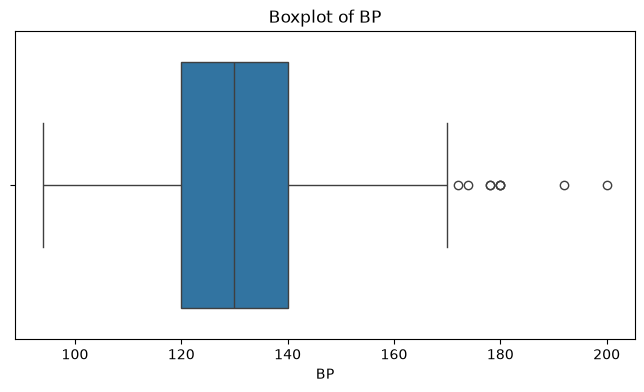

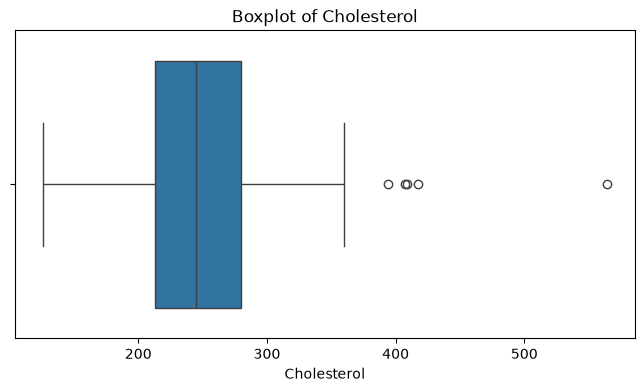

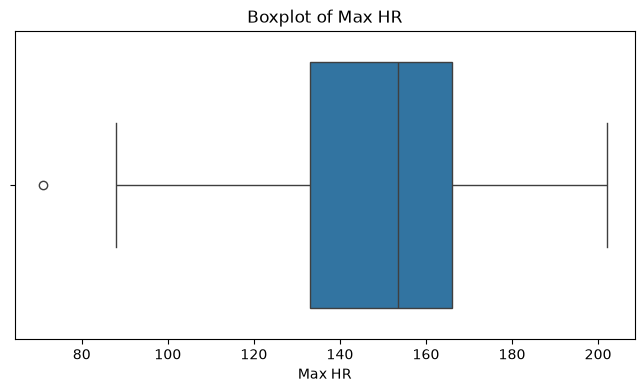

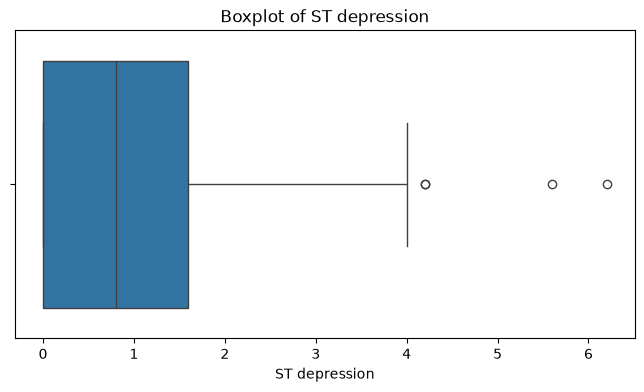

In [34]:
continuous_columns = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression"
]

# Boxplot for each feature
for column in continuous_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

**7. Train Test Split**

In [35]:
print(df["Heart Disease"].value_counts(dropna=False))

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


In [36]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

In [37]:
print("Target column:")
print(df["Heart Disease"].head())

print("\nTarget data type:")
print(df["Heart Disease"].dtype)

print("\nTarget value counts:")
print(df["Heart Disease"].value_counts(dropna=False))

print("\nMissing values:")
print(df["Heart Disease"].isna().sum())

Target column:
0    1
1    0
2    1
3    0
4    0
Name: Heart Disease, dtype: int64

Target data type:
int64

Target value counts:
Heart Disease
0    150
1    120
Name: count, dtype: int64

Missing values:
0


In [38]:
print(df["Heart Disease"].value_counts(dropna=False))
print("Missing values:", df["Heart Disease"].isna().sum())

Heart Disease
0    150
1    120
Name: count, dtype: int64
Missing values: 0


In [39]:
print("Target column:")
print(df["Heart Disease"].head())

print("\nTarget data type:")
print(df["Heart Disease"].dtype)

print("\nTarget value counts:")
print(df["Heart Disease"].value_counts(dropna=False))

print("\nMissing values:")
print(df["Heart Disease"].isna().sum())

Target column:
0    1
1    0
2    1
3    0
4    0
Name: Heart Disease, dtype: int64

Target data type:
int64

Target value counts:
Heart Disease
0    150
1    120
Name: count, dtype: int64

Missing values:
0


**separate x and y**

In [40]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]



In [41]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (270, 13)
y shape: (270,)


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [43]:
# Check the shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

# Check target distribution
print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())



X shape: (270, 13)
y shape: (270,)

Training data:
X_train: (216, 13)
y_train: (216,)

Testing data:
X_test: (54, 13)
y_test: (54,)

Training target distribution:
Heart Disease
0    120
1     96
Name: count, dtype: int64

Testing target distribution:
Heart Disease
0    30
1    24
Name: count, dtype: int64


**8. Data Preprocessing**

In [44]:
if df["Heart Disease"].dtype == "object":
    df["Heart Disease"] = df["Heart Disease"].map({
        "Absence": 0,
        "Presence": 1
    })
    print(df["Heart Disease"].isna().sum())

## Encoding

The categorical variables in the dataset are already represented using numerical
codes. The target variable `Heart Disease` is also already encoded as 0 and 1.
Therefore, additional encoding is not required for this dataset.

**pipeline**

In [45]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])



In [46]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [47]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [48]:

y_pred = pipeline.predict(X_test)
print(y_pred)

[0 0 0 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 1 0 0 1
 0 0 0 1 0 1 1 1 0 1 1 1 1 1 1 0 1]


In [49]:
from sklearn.metrics import accuracy_score

y_train_pred = pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

y_test_pred = pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8518518518518519
Testing Accuracy: 0.8518518518518519


**9.Handled imbalance**

In [50]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Heart Disease
0    150
1    120
Name: count, dtype: int64
Heart Disease
0    55.555556
1    44.444444
Name: proportion, dtype: float64


Difference = 30 records, aur percentage difference ≈ 11.11 percentage points.

👉 55.56% vs 44.44% is reasonably balanced.

Isliye aapke dataset mein SMOTE (oversampling) ya undersampling ki generally zarurat nahi hai.

“The target variable is reasonably balanced, with 55.56% samples in class 0 and 44.44% in class 1. Therefore, no oversampling or undersampling technique was required.”

**10.Model building**

**Model 1 — Logistic Regression**

In [51]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

**Model 2 — SVM**

In [52]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_prob = svm_model.predict_proba(X_test)[:, 1]

**Model 3 — Random Forest**

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

**Model Evaluation**

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_true, y_pred, y_prob):

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(y_true, y_pred))

    print("Recall   :",
          recall_score(y_true, y_pred))

    print("F1 Score :",
          f1_score(y_true, y_pred))

    print("ROC-AUC  :",
          roc_auc_score(y_true, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    

In [55]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)

evaluate_model(
    "SVM",
    y_test,
    svm_pred,
    svm_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


Logistic Regression
Accuracy : 0.8518518518518519
Precision: 0.7857142857142857
Recall   : 0.9166666666666666
F1 Score : 0.8461538461538461
ROC-AUC  : 0.898611111111111

Confusion Matrix:
[[24  6]
 [ 2 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54


SVM
Accuracy : 0.8148148148148148
Precision: 0.7692307692307693
Recall   : 0.8333333333333334
F1 Score : 0.8
ROC-AUC  : 0.8861111111111111

Confusion Matrix:
[[24  6]
 [ 4 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        30
           1       0.77      0.83      0.80        24

    accuracy                           0.81        54
   macro avg       0.

**11. Final Evaluation model**

In [56]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("----- Logistic Regression Evaluation -----")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

----- Logistic Regression Evaluation -----
Accuracy : 0.8519
Precision: 0.7857
Recall   : 0.9167
F1 Score : 0.8462
ROC-AUC  : 0.8986

Confusion Matrix:
[[24  6]
 [ 2 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



**12. Confusion matrix**

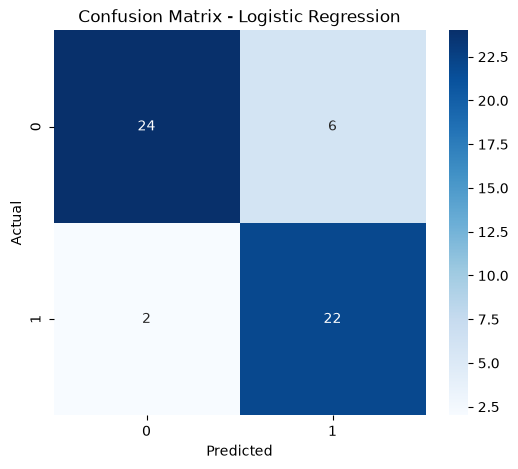

In [57]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

**13. ROC curve**

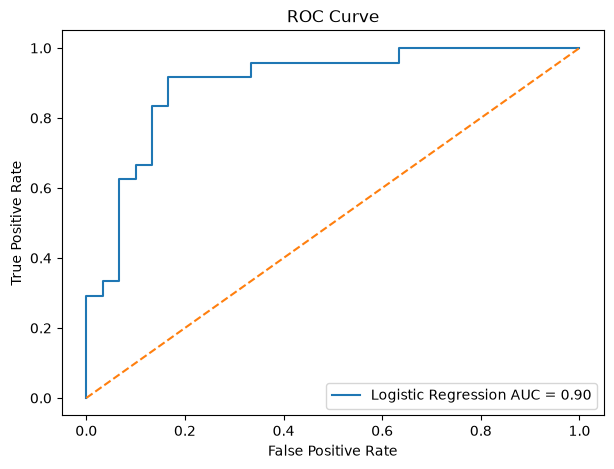

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**14. Cross Validation**

In [59]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("Mean CV Accuracy:",
      scores.mean())

Cross Validation Scores:
[0.87037037 0.88888889 0.77777778 0.77777778 0.87037037]
Mean CV Accuracy: 0.837037037037037


**15. Hyperparameter Tuning**

Use GridSearchCV.

In [60]:


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 0.01, 'model__solver': 'lbfgs'}

Best CV ROC-AUC:
0.9157894736842105


In [61]:
best_model = grid_search.best_estimator_

final_pred = best_model.predict(X_test)

final_prob = best_model.predict_proba(X_test)[:, 1]

evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    final_pred,
    final_prob
)


Tuned Logistic Regression
Accuracy : 0.8518518518518519
Precision: 0.8333333333333334
Recall   : 0.8333333333333334
F1 Score : 0.8333333333333334


ROC-AUC  : 0.9083333333333333

Confusion Matrix:
[[26  4]
 [ 4 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.83      0.83      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



**16. Download the updated dataset as csv file**

In [62]:
df.to_csv("Clean Heart Disease Prediction.csv",index=False)

**17. Feature Importance**

                    Feature  Coefficient  Absolute
11  Number of vessels fluro     0.249561  0.249561
12                 Thallium     0.247785  0.247785
2           Chest pain type     0.216433  0.216433
8           Exercise angina     0.183258  0.183258
1                       Sex     0.182234  0.182234
9             ST depression     0.165207  0.165207
7                    Max HR    -0.162249  0.162249
10              Slope of ST     0.132409  0.132409
0                       Age     0.075219  0.075219
6               EKG results     0.066837  0.066837
3                        BP     0.060057  0.060057
4               Cholesterol     0.046282  0.046282
5              FBS over 120    -0.032780  0.032780


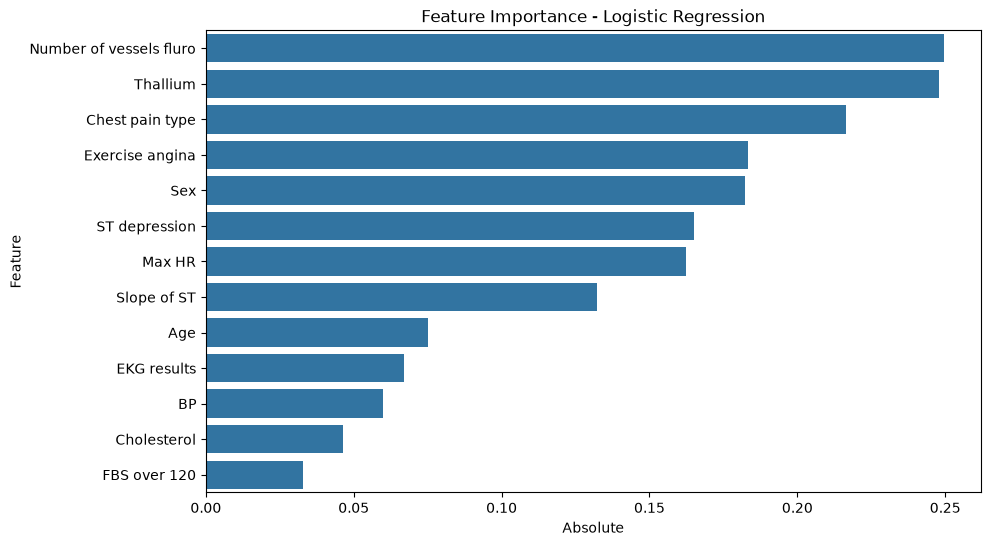

In [63]:
coefficients = best_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

feature_importance["Absolute"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute",
    ascending=False
)

print(feature_importance)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Absolute",
    y="Feature"
)

plt.title("Feature Importance - Logistic Regression")

plt.show()

In [64]:
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0
